# House Price Prediction

## Project Objective
The objective of this project is to develop a machine learning model capable of predicting house prices based on various property characteristics such as area, number of bedrooms, bathrooms, stories, parking availability, and additional amenities. The project aims to analyze the factors that influence house prices, perform data cleaning and preprocessing, and build predictive models using regression techniques. By comparing the performance of Linear Regression and Random Forest Regressor models, the project seeks to identify the most effective approach for estimating house prices. The findings can help support data-driven decision-making in the real estate industry.

## Task 1: Data Loading and Exploration


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(545, 13)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Target Variable: price

Feature Variables:
area
bedrooms
bathrooms
stories
mainroad
guestroom
basement
hotwaterheating
airconditioning
parking
prefarea
furnishingstatus

## Task 2: Data Cleaning



In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [11]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [12]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


## Task 3: Model Building



In [14]:
X = df.drop("price", axis=1)

y = df["price"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Model 1: Linear Regression

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
lr_pred = lr.predict(X_test)

In [18]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = mean_squared_error(
    y_test,
    lr_pred
) ** 0.5

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2: 0.6529242642153184


### Model 2: Random Forest

In [19]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
rf_pred = rf.predict(X_test)

In [21]:
rf_pred = rf.predict(X_test)

In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


### Model Comparison

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


## Task 4: Visualizations



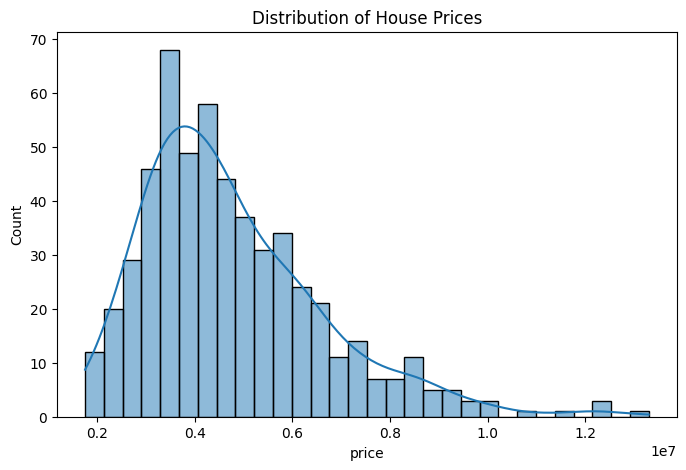

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")

plt.savefig(
    "charts/price_distribution.png"
)

plt.show()

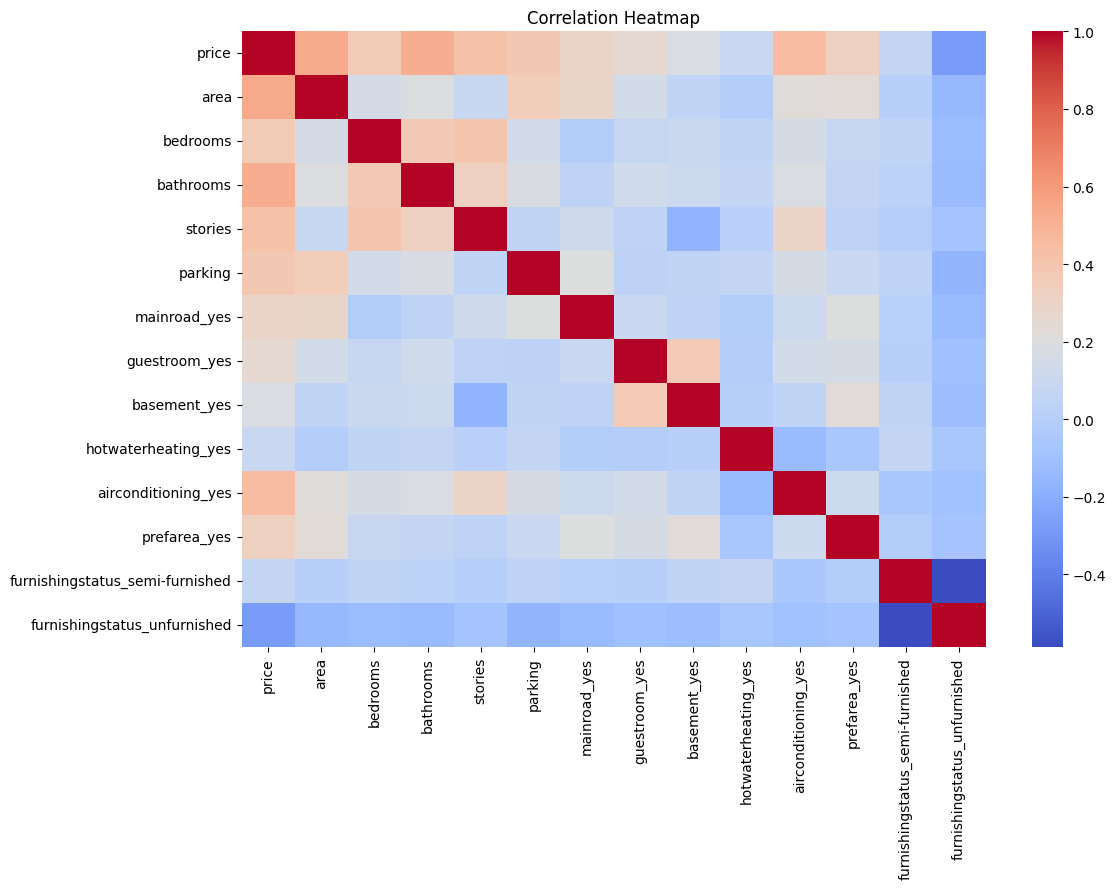

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png"
)

plt.show()

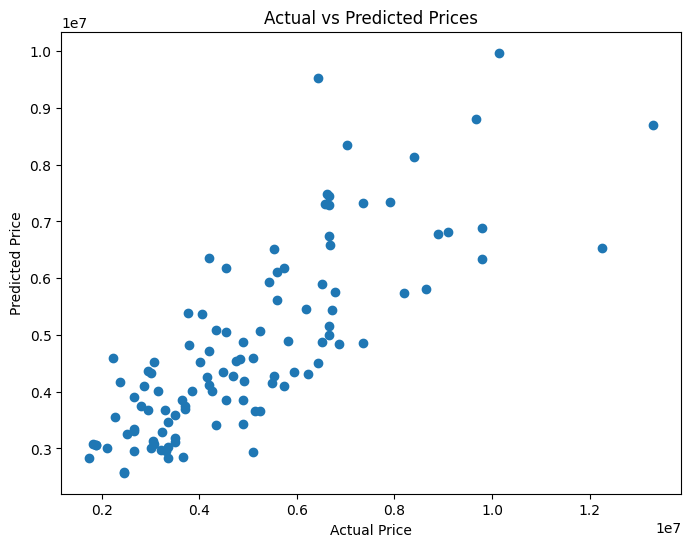

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    "Actual vs Predicted Prices"
)

plt.savefig(
    "charts/actual_vs_predicted.png"
)

plt.show()

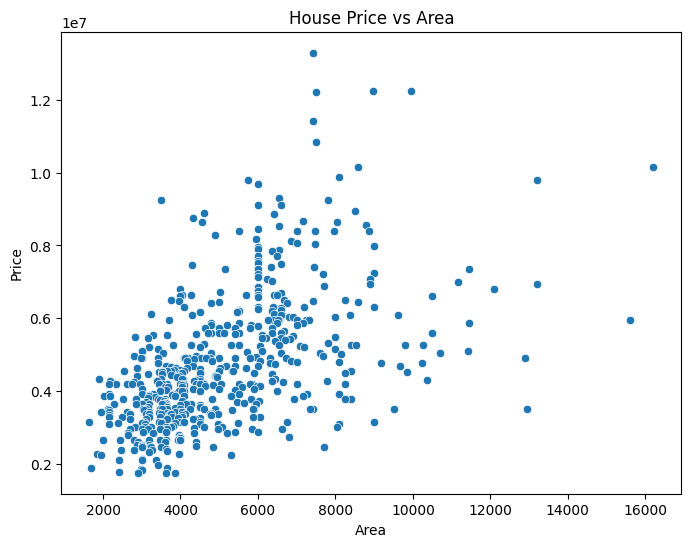

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='area',
    y='price',
    data=df
)

plt.title('House Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')

plt.savefig('charts/price_vs_area.png')

plt.show()

In [28]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

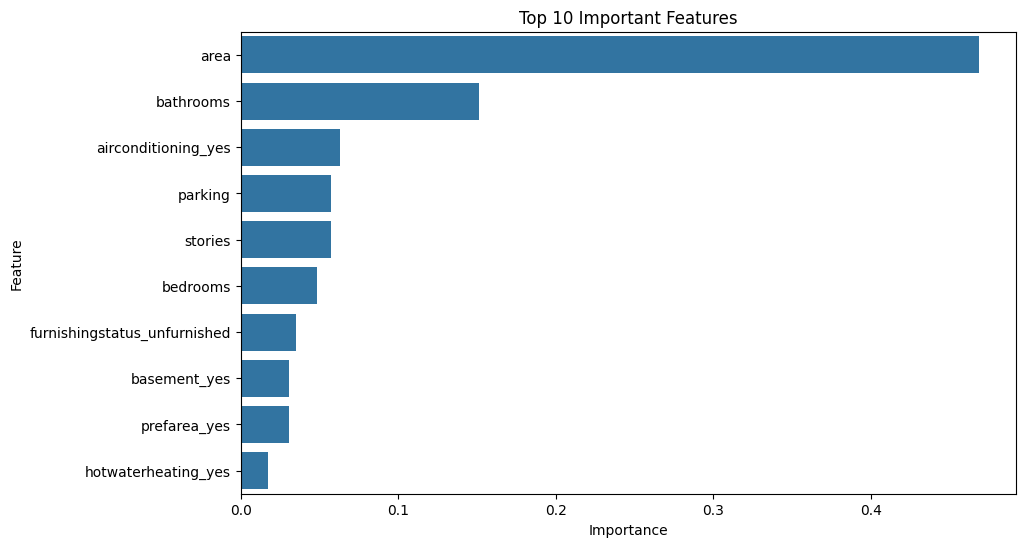

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title(
    'Top 10 Important Features'
)

plt.savefig(
    'charts/feature_importance.png'
)

plt.show()

In [31]:
feature_importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [32]:
housing_raw = pd.read_csv("Housing.csv")

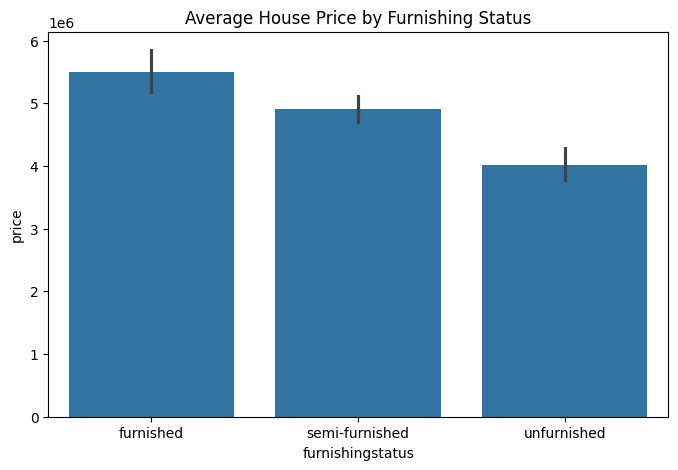

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='furnishingstatus',
    y='price',
    data=housing_raw
)

plt.title('Average House Price by Furnishing Status')

plt.savefig(
    'charts/furnishing_status_price.png'
)

plt.show()

## Task 5: Insights & Summary

The analysis revealed that **area** is the most influential factor affecting house prices, contributing nearly 47% of the overall feature importance. Other important factors include the number of bathrooms, air conditioning availability, parking spaces, and the number of stories. These features significantly impact the market value of residential properties.

Two machine learning models were evaluated: Linear Regression and Random Forest Regressor. The Linear Regression model performed better, achieving an R² score of **0.653**, which means it was able to explain approximately **65% of the variation in house prices**. It also produced lower prediction errors compared to the Random Forest model.

One surprising finding was that amenities such as **air conditioning and parking facilities** had a noticeable influence on house prices, even though they are not major structural characteristics like area or number of bedrooms.

Based on these findings, real estate businesses should focus on highlighting property size, bathroom count, parking availability, and premium amenities when pricing and marketing homes, as these factors have the greatest impact on property value.

## Conclusion

This project successfully developed machine learning models to predict house prices using various housing characteristics. The dataset was cleaned, explored, and analyzed using visualization techniques and regression models. Among the models tested, Linear Regression achieved the best performance with an R² score of 0.653, indicating a reasonably accurate prediction capability. The analysis identified area, bathrooms, air conditioning, parking, and stories as the key factors influencing house prices. Overall, the project demonstrates how machine learning can support data-driven decision-making in the real estate industry by providing reliable property price estimates.